In [1]:
!pip install xgboost catboost lightgbm optuna

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## Import All Libraries

In [2]:
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

# Models
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.ensemble import ExtraTreesRegressor

# Boosting
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor

# Evaluation Metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Tuning
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, cross_val_score

## Load Dataset

In [3]:
df = pd.read_csv('StudentsPerformance.csv')
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [4]:
df.columns = df.columns.str.replace(" ", "_")

df.columns

Index(['gender', 'race/ethnicity', 'parental_level_of_education', 'lunch',
       'test_preparation_course', 'math_score', 'reading_score',
       'writing_score'],
      dtype='object')

## Features Enginerring

In [5]:
# Crate Total Score
df['total_score'] = df['math_score']+ df['reading_score'] + df['writing_score']

# Average Score
df['average_score'] = df['total_score'] / 3

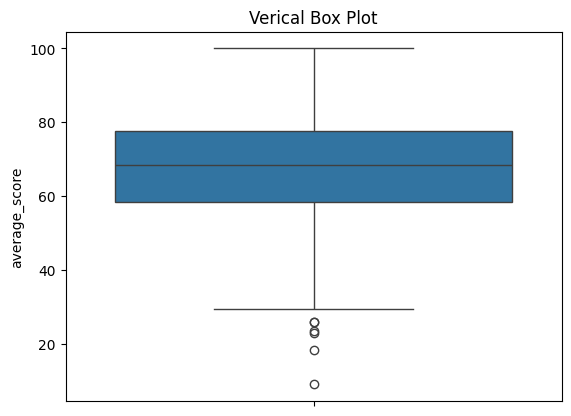

In [6]:
# Box Plot
sns.boxplot(y=df['average_score'])
plt.title('Verical Box Plot')
plt.show()

## Remove Outliers

In [7]:
Q1 = df['average_score'].quantile(0.25)
Q3 = df['average_score'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df = df[
    (df['average_score'] >= lower) &
    (df['average_score'] <= upper)
]

## Features and Target

In [8]:
X = df.drop('math_score', axis=1)
y = df['math_score']

## Separate Numerical and Categorical Columns

In [9]:
# For Numerical
numerical_features = X.select_dtypes(
    exclude='object'
).columns

# For categorical
categorical_features = X.select_dtypes(include='object').columns

## Train Test Split

In [10]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2, random_state=42)

## Preprocessing Pipeline

In [13]:
numeric_transformer = Pipeline(steps = [('scaler', StandardScaler())])
categorical_transformer = Pipeline(steps = [('encoder', OneHotEncoder(handle_unknown='ignore'))])

preprocessor = ColumnTransformer(
    transformers=[
        (
            'num',
            numeric_transformer,
            numerical_features
        ),
        (
            'cat',
            categorical_transformer,
            categorical_features
        )
    ]
)

## Models

In [16]:
models = {
    "Linear regression":LinearRegression(),
    "Decision Tree":DecisionTreeRegressor(),
    "Random Forest":RandomForestRegressor(),
    "Gradient Boosting":GradientBoostingRegressor(),
    "Extra Tree": ExtraTreesRegressor(),
    "SVR":SVR(),
    "XGBoost": XGBRegressor(),
    "CatBoost": CatBoostRegressor(),
    "LightGBM":LGBMRegressor()
}

## Model Training and Evaluation

In [23]:
from sklearn.metrics import r2_score

results = {}

for name, model in models.items():

    pipeline = Pipeline(
        steps=[
            ('preprocessor', preprocessor),
            ('model', model)
        ]
    )

    pipeline.fit(X_train, y_train)

    y_pred = pipeline.predict(X_test)

    r2 = r2_score(y_test, y_pred)

    results[name] = r2

    print(f"{name} : {r2}")

Linear regression : 1.0
Decision Tree : 0.9317328667039649
Random Forest : 0.966891855294601
Gradient Boosting : 0.9580254179270167
Extra Tree : 0.9536593376947423
SVR : 0.8706823548409384
XGBoost : 0.976080060005188
Learning rate set to 0.039485
0:	learn: 14.1831949	total: 340ms	remaining: 5m 39s
1:	learn: 13.7857356	total: 366ms	remaining: 3m 2s
2:	learn: 13.3804018	total: 388ms	remaining: 2m 9s
3:	learn: 12.9755048	total: 415ms	remaining: 1m 43s
4:	learn: 12.6128077	total: 443ms	remaining: 1m 28s
5:	learn: 12.2502124	total: 462ms	remaining: 1m 16s
6:	learn: 11.8917989	total: 482ms	remaining: 1m 8s
7:	learn: 11.5658862	total: 508ms	remaining: 1m 3s
8:	learn: 11.2223407	total: 537ms	remaining: 59.1s
9:	learn: 10.9268771	total: 565ms	remaining: 55.9s
10:	learn: 10.6180532	total: 592ms	remaining: 53.2s
11:	learn: 10.3533504	total: 611ms	remaining: 50.3s
12:	learn: 10.1130888	total: 639ms	remaining: 48.5s
13:	learn: 9.8535876	total: 660ms	remaining: 46.5s
14:	learn: 9.6097054	total: 669m

D:\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


## Best Model

In [24]:
best_model_name = max(results, key=results.get)
print("Best Model : ", best_model_name)

Best Model :  Linear regression


## Hyperparameter Tuning (XGBoost)

In [25]:
xgb_pipeline = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('model', XGBRegressor())
    ]
)
params = {
    'model__n_estimators':
        [100, 200, 300],

    'model__learning_rate':
        [0.01, 0.05, 0.1],

    'model__max_depth':
        [3, 5, 7],

    'model__subsample':
        [0.7, 0.8, 1.0],

    'model__colsample_bytree':
        [0.7, 0.8, 1.0]
}


random_search = RandomizedSearchCV(

    estimator=xgb_pipeline,

    param_distributions=params,

    n_iter=20,

    cv=5,

    scoring='r2',

    verbose=1,

    n_jobs=-1,

    random_state=42
)

random_search.fit(X_train, y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


RandomizedSearchCV(cv=5,
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('num',
                                                                               Pipeline(steps=[('scaler',
                                                                                                StandardScaler())]),
                                                                               Index(['reading_score', 'writing_score', 'total_score', 'average_score'], dtype='object')),
                                                                              ('cat',
                                                                               Pipeline(steps=[('encoder',
                                                                                                OneHotEncoder(handle_unknown='ignore'))]),
                                                                               Index(['gender', 'race/ethnicity', 'pa...
                                                           monotone_constraints=None,
                                                           multi_strategy=None,
                                                           n_estimators=None,
                                                           n_jobs=None,
                                                           num_parallel_tree=None, ...))]),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'model__colsample_bytree': [0.7, 0.8,
                                                                    1.0],
                                        'model__learning_rate': [0.01, 0.05,
                                                                 0.1],
                                        'model__max_depth': [3, 5, 7],
                                        'model__n_estimators': [100, 200, 300],
                                        'model__subsample': [0.7, 0.8, 1.0]},
                   random_state=42, scoring='r2', verbose=1)

## Best Parameters

In [26]:
print(random_search.best_params_)

{'model__subsample': 0.7, 'model__n_estimators': 300, 'model__max_depth': 5, 'model__learning_rate': 0.1, 'model__colsample_bytree': 0.8}


## Final Best Model

In [27]:
best_model = random_search.best_estimator_

best_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  Index(['reading_score', 'writing_score', 'total_score', 'average_score'], dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['gender', 'race/ethnicity', 'parental_level_of_education', 'lunch'...
                              feature_types=None, feature_weights=None,
                              gamma=None, grow_policy=None,
                              importance_type=None,
                              interaction_constraints=None, learning_rate=0.1,
                              max_bin=None, max_cat_threshold=None,
                              max_cat_to_onehot=None, max_delta_step=None,
                              max_depth=5, max_leaves=None,
                              min_child_weight=None, missing=nan,
                              monotone_constraints=None, multi_strategy=None,
                              n_estimators=300, n_jobs=None,
                              num_parallel_tree=None, ...))])

## Prediction

In [28]:
y_pred = best_model.predict(X_test)

## Final Metrics

In [29]:
mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print("MAE :", mae)

print("MSE :", mse)

print("RMSE :", rmse)

print("R2 Score :", r2)

MAE : 1.3305697441101074
MSE : 3.0838851928710938
RMSE : 1.756099425679279
R2 Score : 0.986410915851593


## Cross Validation

In [30]:
scores = cross_val_score(
    best_model,
    X,
    y,
    cv=5,
    scoring='r2'
)

print(scores)

print("Average CV Score :", scores.mean())

[0.9826591  0.98309076 0.98133069 0.98439068 0.98541325]
Average CV Score : 0.9833768963813782


## Feature Importance

In [31]:
model = best_model.named_steps['model']

importance = model.feature_importances_

print(importance)

[0.01298398 0.01106382 0.19389598 0.5173742  0.1434473  0.02580931
 0.0035476  0.00213182 0.00313114 0.00316802 0.0119443  0.0022821
 0.00244267 0.00336339 0.00363489 0.00206061 0.00250565 0.01487452
 0.01579864 0.0088062  0.01573377]


## Actual vs Predicted Graph

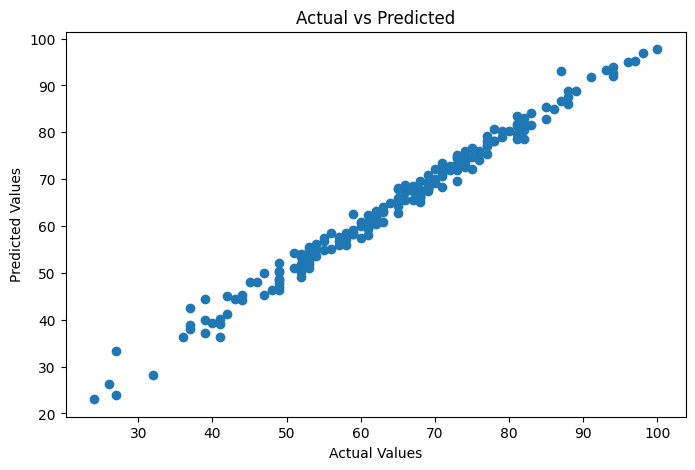

In [32]:
plt.figure(figsize=(8,5))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Values")

plt.ylabel("Predicted Values")

plt.title("Actual vs Predicted")

plt.show()

## Save Model

In [34]:
import pickle
pickle.dump(
    best_model,
    open("best_model.pkl", "wb")
)

## Load Model

In [35]:
loaded_model = pickle.load(
    open("best_model.pkl", "rb")
)

## Predict New Student

In [36]:
sample = X_test.iloc[0:1]

prediction = loaded_model.predict(sample)

print("Predicted Score :", prediction)

Predicted Score : [73.812675]
